Esto funciona unicamente si se ejecuta con el interprete limpio

In [1]:
%load_ext memory_profiler
import pandas as pd
import numpy as np
import sys
import gc

Hay que crear elementos realmente grandes porque sino utiliza memoria previa para no volver a pedir y no se logra ver el incremento.

In [2]:
%memit
CANTIDAD = 10000000
df = pd.DataFrame({"col1": np.random.rand(CANTIDAD),
                   "col2": np.random.randint(0, 100, CANTIDAD),
                   })
#df["col1"] = df["col1"].astype(object)
mask = np.random.choice(
    [False, True], 
    size=len(df["col1"]), 
    p=[1 - 0.5, 0.5]
)
idxs = df["col1"].index[mask]
df.loc[idxs, "col1"] = f"{df.loc[idxs, 'col1'].values[0]}"
print(df.dtypes)    
%memit

peak memory: 98.85 MiB, increment: 0.09 MiB
col1    object
col2     int32
dtype: object
peak memory: 644.12 MiB, increment: 0.00 MiB


La creación de la función no tiene costo, la acción esta cuando la llamo

In [3]:
def fun_trans(X):
    X = df[[ "col1" ]].copy()
    X = X.astype({"col1": "float"})
    return X


Que pasa si lo hago fuera de una función

In [4]:
%memit
X = df[[ "col1" ]].copy()
X = X.astype({"col1": "float"})
%memit

peak memory: 644.13 MiB, increment: 0.00 MiB
peak memory: 720.53 MiB, increment: 0.00 MiB


Tenemos un incremento, una nueva variable (X) dando vueltas sin un destino...

In [5]:
%memit
df["col1"] = X
%memit

peak memory: 721.68 MiB, increment: 0.00 MiB
peak memory: 416.68 MiB, increment: 0.00 MiB


Ocupa menos ahora a pesar de de que la variable X sigue viva ¿Como puede ser? Guardar los valores en flotantes es mas barato que guardarlos como objetos.  

In [6]:
del X
%memit

peak memory: 340.80 MiB, increment: 0.00 MiB


Todavía menos...  
Volvamos a generar el dataset pisando lo anterior...

In [7]:
%memit
CANTIDAD = 10000000
df = pd.DataFrame({"col1": np.random.rand(CANTIDAD),
                   "col2": np.random.randint(0, 100, CANTIDAD),
                   })
#df["col1"] = df["col1"].astype(object)
mask = np.random.choice(
    [False, True], 
    size=len(df["col1"]), 
    p=[1 - 0.5, 0.5]
)
idxs = df["col1"].index[mask]
df.loc[idxs, "col1"] = f"{df.loc[idxs, 'col1'].values[0]}"
print(df.dtypes)    
%memit

peak memory: 340.98 MiB, increment: 0.00 MiB
col1    object
col2     int32
dtype: object
peak memory: 645.95 MiB, increment: 0.00 MiB


Estamos mas o menos igual de memoria, tiene sentido. Transformemos vía función

In [8]:
%memit
df["col1"] = fun_trans(df[["col1"]])
%memit

peak memory: 645.60 MiB, increment: 0.00 MiB
peak memory: 341.64 MiB, increment: 0.00 MiB


Quedamos en 341 porque el flotante ocupa menos que el object ¿Y el X? El X se asignó como columna, posiblemente le GC lo liberó, siquiera figura en la lista de variables. Como la variable X era local a la función finalizada esta, nada la puede apuntar, contador de referencia == 0 y es liberada.

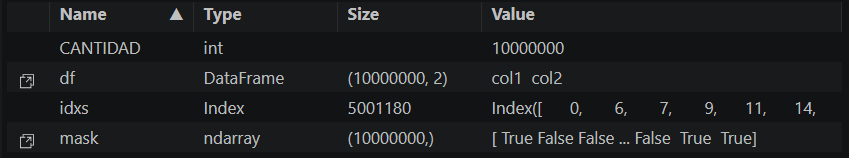

In [9]:
del idxs
del mask
gc.collect()
%memit

peak memory: 294.14 MiB, increment: 0.00 MiB
